# Homework 10: Classification - Solutions

**Attention:**

1. **Using the Notebook**
    - Use Jupyter Notebook as instructed. We do **not** have the resources to support Anaconda or VS Code. 
    - Provide your answers in the designated spaces.
    - Do not reassign variables! For example, if you use `max_temperature` for one question, do not reassign it later on (e.g., as an intermediate variable). Doing so may cause you to fail tests you passed previously!
2. **Grading**:
    - Points may be scaled in Canvas.
    - Most tests check the format and data types of your answers, not their correctness. Passing the tests does not guarantee the grade will be 100%.
3. Academic honor:
    - **DO NOT CHEAT!** Academic honor matters.  
    - <font color='darkred'>**Use AI to LEARN, not to cheat**. **DO NOT copy-and-paste**</font>. Your advantage comes from your knowledge and skills on the subject. Do not rely on AI. 
    - Collaboration and using resources are encouraged, but **DO NOT directly share answers**. Always answer the questions and solve the problems by yourself. 
4. Getting help:
    - Attend the TA's help sessions and the instructor's office hours.
5. <font color="darkred">**Time management**</font>: Start early in the assignment cycle and allocate enough time to complete the assignment properly.

In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw10.ipynb")

In [2]:
# Don't change this cell; just run it. 

import numpy as np
import pandas as pd
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

import warnings
warnings.simplefilter('ignore')

from datetime import datetime

## 1. Bay Area School Coordinates with Classification

This homework is about k-Nearest Neighbors classification (k-NN). The purpose of this homework is to reinforce the basics of this method. 

### Our Dearest Neighbors

Carol is trying classify students as either attendees of UC Berkeley or as attendees of Stanford University. To classify the students, Carol has access to the coordinates of the location they live during the school year. First, load in the `coordinates` table.

In [3]:
### just run this cell!
coordinates = pd.read_csv('coordinates.csv')
coordinates

,latitude,longitude,school
0,37.869304,-122.254946,Berkeley
1,37.865051,-122.255582,Berkeley
2,37.866116,-122.253733,Berkeley
3,37.868049,-122.259579,Berkeley
4,37.868286,-122.256581,Berkeley
...,...,...,...
95,37.465370,-122.197002,Stanford
96,37.399869,-122.090946,Stanford
97,37.367410,-121.977035,Stanford
98,37.426077,-121.903974,Stanford


As usual, let's investigate our data visually before performing any kind of numerical analysis.

<Axes: xlabel='longitude', ylabel='latitude'>

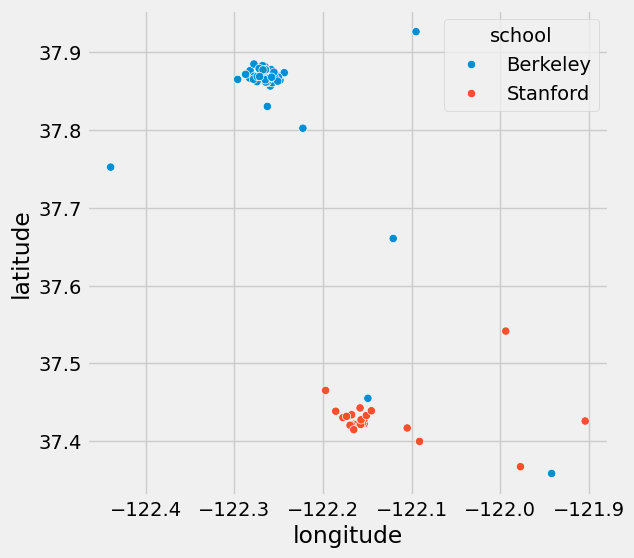

In [4]:
import seaborn as sns
plt.figure(figsize=(6,6))
sns.scatterplot(data=coordinates, x="longitude", y="latitude", hue="school")

The locations of the points on this scatter plot might be familiar - run the following cell to see what they correspond to.

In [5]:
colors = {"Berkeley": "blue", "Stanford": "red"}
coordinates["color"] = coordinates["school"].map(colors)

%pip install folium --quiet
import folium

m = folium.Map(
    location=[coordinates["latitude"].mean(), coordinates["longitude"].mean()],
    zoom_start=10
)

# Plot each row
for _, row in coordinates.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
        color=row["color"],
        fill=True,
        fill_opacity=1
    ).add_to(m)
m


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


**Question 1.1.** Let's begin implementing the k-Nearest Neighbors algorithm. Define the `distance` function, which takes in two arguments: an array of numerical features (`arr1`), and a different array of numerical features (`arr2`). The function should return the [Euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) between the two arrays. Euclidean distance is often referred to as the straight-line distance formula. **(10 points)**

*Note:* Features refer to the characteristics of data used for machine learning models to predict with. In table format, these are the columns.

In [6]:
def distance(arr1, arr2):
    return np.sqrt(np.sum((arr1 - arr2) ** 2))

# Don't change/delete the code below in this cell
distance_example = distance(make_array(1, 2, 3), make_array(4, 5, 6))
distance_example

5.196152422706632

In [7]:
grader.check("q1_1")

q1_1 results: All test cases passed!

### Splitting the Dataset
We'll do two different kinds of things with the `coordinates` dataset:

1. We'll build a classifier using coordinates for which we know the associated label; this will teach it to recognize labels of similar coordinate values. This process is known as *training*.
2. We'll evaluate or *test* the accuracy of our classifier on data we haven't seen before.

As discussed in [here](https://thinkdsm.org/chapters/10-classification/1002_training_and_testing.html#), we want to use separate datasets for training and testing. As such, we split up our one dataset into two.

**Question 1.2.** Next, let's split our dataset into a training set and a test set. Since `coordinates` has 100 rows, let's create a training set with the first 75 rows and a test set with the remaining 25 rows. Remember that assignment to each group should be random, so we should shuffle the table first. **(10 points)**

*Hint:* As a first step we can shuffle all the rows, then use the `tbl.take` function to split up the rows for each table.


In [8]:
shuffled_table = coordinates.sample(len(coordinates), replace=False)
train = shuffled_table.take(np.arange(75))
test = shuffled_table.take(np.arange(75, 100))

train.num_rows = len(train)
test.num_rows = len(test)

print("Training set:\t",   len(train), "examples")
print("Test set:\t",       len(test), "examples")
print(train.head(5), '\n')
print(test.head(5))

Training set:	 75 examples
Test set:	 25 examples
     latitude   longitude    school color
42  37.861107 -122.262144  Berkeley  blue
17  37.872008 -122.268462  Berkeley  blue
55  37.861344 -122.264583  Berkeley  blue
54  37.864989 -122.278434  Berkeley  blue
80  37.430436 -122.177451  Stanford   red 

     latitude   longitude    school color
56  37.867223 -122.262721  Berkeley  blue
79  37.433092 -122.168520  Stanford   red
92  37.438658 -122.185528  Stanford   red
53  37.868927 -122.277466  Berkeley  blue
86  37.420623 -122.169417  Stanford   red


In [9]:
grader.check("q1_2")

q1_2 results: All test cases passed!

**Question 1.3.** Assign `features` to an array of column names (strings) of the features from the `coordinates` table. **(10 points)**

*Hint:* Which of the column names in the `coordinates` table are the features, and which of the column names correspond to the class we're trying to predict?

*Hint*: No need to modify any tables, just manually create an array of the feature names!


In [10]:
coordinates.labels = coordinates.columns.tolist()

features = np.array(["latitude", "longitude"])
features

array(['latitude', 'longitude'],
      dtype='<U9')

In [11]:
grader.check("q1_3")

q1_3 results: All test cases passed!

**Question 1.4.** Now define the `classify` function. This function should take in a `test_row` from a table like `test` and classify it using the k-Nearest Neighbors based on the correct `features` and the data in `train`. A refresher on k-Nearest Neighbors can be found [here](https://www.inferentialthinking.com/chapters/17/4/Implementing_the_Classifier.html). **(10 points)**


*Hint 1:* The `distance` function we defined earlier takes in arrays as input, so use the `row_to_array` function we defined for you to convert rows to arrays of features.

*Hint 2:* The skeleton code we provided iterates through each row in the training set. `train_row` is a row object.


In [12]:
def row_to_array(row, features):
    """Converts a row to an array of its features."""
    if isinstance(row, pd.Series):
        s = row
    else:
        # Otherwise assume it's a datascience Row; convert to dict, then to Series
        s = pd.Series(row.asdict())

    arr = np.array([])
    for feature in features:
        arr = np.append(arr, s[feature])
    return arr

def classify(test_row, k, train):
    test_row_features_array = row_to_array(test_row, features)
    distances = np.array([])
    for train_row in train.iterrows():
        train_row_features_array = row_to_array(train_row[1], features)
        row_distance = distance(test_row_features_array, train_row_features_array)
        distances = np.append(distances, row_distance)
    train_with_distances = train.copy()
    train_with_distances['distance'] = distances
    nearest_neighbors = train_with_distances.nsmallest(k, 'distance')
    most_common_label = nearest_neighbors['school'].mode()[0]
    return most_common_label

# Don't modify/delete the code below
first_test = classify(test.iloc[0], 5, train)
first_test

'Berkeley'

In [13]:
grader.check("q1_4")

q1_4 results: All test cases passed!

**Question 1.5.** Define the function `three_classify` that takes a `row` from `test` as an argument and classifies the row based on using 3-Nearest Neighbors. Use this function to find the `accuracy` of a 3-NN classifier on the `test` set. `accuracy` should be a proportion (not a percentage) of the schools that were correctly predicted. **(10 points)**


*Hint:* You should be using a function you just created!

*Note:* Usually before using a classifier on a test set, we'd classify first on a "validation" set, which we then can modify our training set again if need be, before actually testing on the test set. You don’t need to do that for this question, but you will learn about this more in Data 100.


In [14]:
def three_classify(row):
    return classify(row, 3, train)

test_with_prediction = test.copy()
test_with_prediction['prediction'] = test.apply(three_classify, axis=1)

labels_correct = (test_with_prediction['school'] == test_with_prediction['prediction']).sum()

accuracy = labels_correct / len(test)
accuracy

from datascience import Table
coordinates = Table.read_table("coordinates.csv")
sorted_coordinates = coordinates.sort("school")


In [36]:
grader.check("q1_5")

q1_5 results: All test cases passed!

**Question 1.6.** There are 77 rows of Berkeley students and 23 rows of Stanford students in the `coordinates` table. If we used the entire `coordinates` table as the training set, what is the smallest value of k that would ensure that a k-Nearest Neighbor classifier would *always* predict Berkeley as the class? Assign the value to `k`. **(10 points)**

> **Note:** Section [20.2](https://thinkdsm.org/chapters/10-classification/1002_training_and_testing.html) from the textbook may be useful here!

In [37]:
k = 24
k

24

In [38]:
grader.check("q1_6")

q1_6 results: All test cases passed!

<!-- BEGIN QUESTION -->

**Question 1.7.1** When doing Knn classification we split our data into training and test sets.

Why do we divide our data into training and test sets? Or in other words what is the point of the training set? What is the point of the test set?
**(7 points)**

> *Hint:* Check out this [section](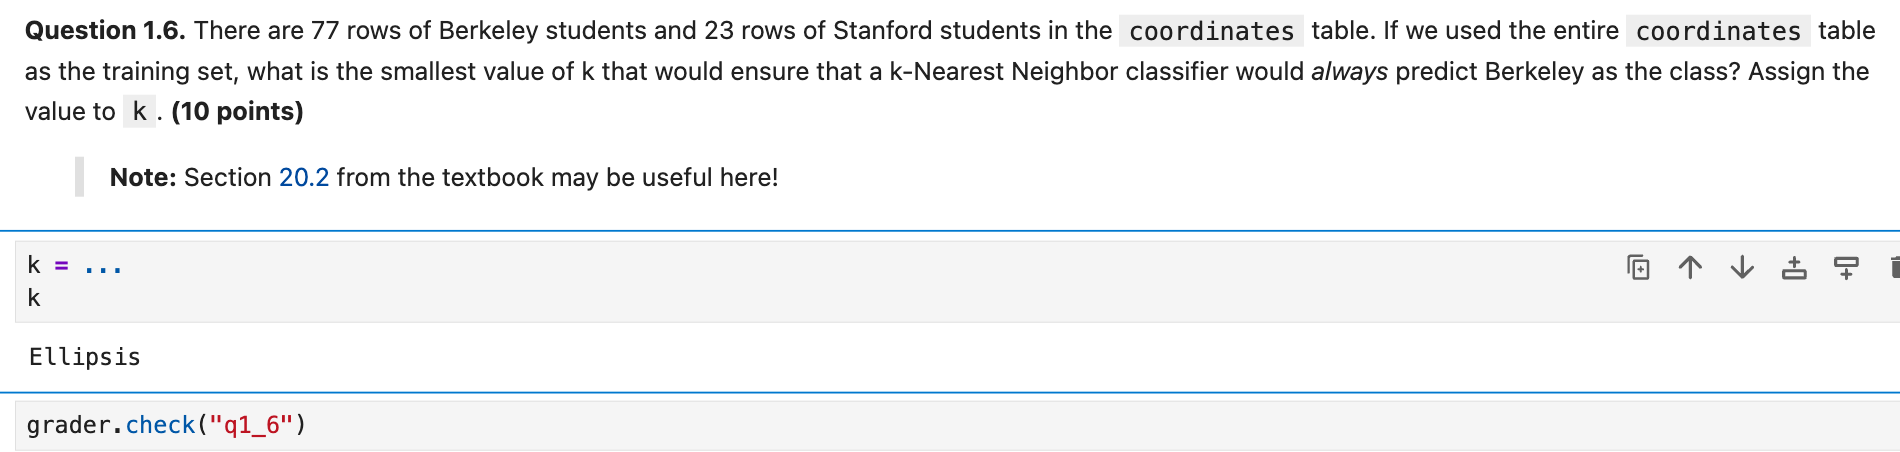l) in the textbook.

> ***Note:** Please answer both questions*


_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 1.7.2** Why do we only want to use the test set once? **(3 points)**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 1.8.** Why do we choose `k` to be an odd number in k-NN? Explain. **(10 points)**


_Type your answer here, replacing this text._

<!-- END QUESTION -->

**Question 1.9.0. Setup**

Thomas has devised a scheme for splitting up the test and training set. For each row from `coordinates`:
- Rows for Stanford students have a 50% chance of being placed in the training set and 50% chance of being placed in the test set.  
- Rows for Berkeley students have a 80% chance of being placed in the training set and 20% chance of being placed in the test set.  


*Hint 1:* Remember that there are 77 Berkeley students and 23 Stanford students in coordinates.  

*Hint 2:* [18.1](https://inferentialthinking.com/chapters/18/1/More_Likely_than_Not_Binary_Classifier.html#bayes-rule) from the original textbook may be helpful here!

**Question 1.9.1.** Given that a row is in the test set, what is the probability that it corresponds to a Stanford student? Assign that probability to `prob_furd`. **(10 points)**

> ***Note:*** **Do not round this value; calculate it exactly.**

In [39]:
prob_furd = 11.5 / 26.9
prob_furd

0.42750929368029744

In [40]:
grader.check("q1_9_1")

q1_9_1 results: All test cases passed!

**Question 1.9.2.** Given that a row is Stanford, what is the probability that the student is in the test set? Assign that probability to `prob_test`. **(10 points)**


In [41]:
prob_test = 0.5
prob_test

0.5

In [42]:
grader.check("q1_9_2")

q1_9_2 results: All test cases passed!

<p>&nbsp;</p>

## Submission Instructions

Follow these steps to submit your work:

1. Save your notebook file:
   - Click on File -> Save Notebook, or simply click on the Save icon.
2. Restart Kernel and Run All Cells:
   - In the menu, go to Kernel → Restart Kernel and Run All Cells.
3. Verify your work:
   - Scroll through the notebook to ensure everything runs smoothly without unexpected error messages. 
   - In case of interruptions caused by execution errors, you may use Run Selected Cell and All Below to continue execution. 
4. Save the notebook again to confirm all changes.
5. Upload your notebook to Canvas.